# FRTB IMA Risk Monitor — Methodology

A walk-through of the risk methodology behind the [FRTB IMA Risk Monitor](https://github.com/marksguo/frtb-ima-risk-monitor): Historical-Simulation VaR and Expected Shortfall, how the choice of distributional assumption changes the tail estimate, and how the model holds up under formal VaR backtests.

Everything below is computed live from market data via the project's own `fetch_prices` module, so the notebook is self-contained (no database needed).

In [1]:
%matplotlib inline
import sys, pathlib
root = pathlib.Path.cwd()
if not (root / 'pipeline').exists() and (root.parent / 'pipeline').exists():
    root = root.parent
sys.path.insert(0, str(root))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True, 'grid.alpha': 0.3})
from pipeline.fetch_prices import fetch_prices
from pipeline.config import WEIGHTS, TICKERS, VAR_WINDOW, ALPHA
from pipeline.var_methods import compare_methods
from pipeline.calculate_risk import rolling_var_es
from pipeline.var_backtests import kupiec_pof, christoffersen, breaches_from
print('Imports OK')

Matplotlib is building the font cache; this may take a moment.


Imports OK


## 1. The synthetic trading book

Six liquid ETFs, one per FRTB asset class (equity, rates, credit, EM equity, commodity, FX), held at equal notional weight. Daily portfolio P&L is the equal-weighted mean of the asset returns.

4,812 trading days | 2007-04-12 to 2026-05-27


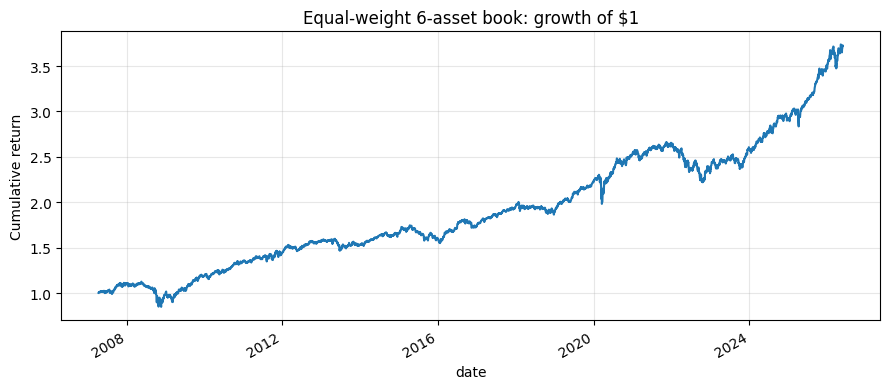

In [2]:
prices = fetch_prices()
wide = prices.pivot(index='date', columns='ticker', values='daily_return')[TICKERS].dropna()
port = (wide * pd.Series(WEIGHTS)).sum(axis=1)
print(f'{len(port):,} trading days | {wide.index.min().date()} to {wide.index.max().date()}')
((1 + port).cumprod()).plot(title='Equal-weight 6-asset book: growth of $1', color='#1f77b4')
plt.ylabel('Cumulative return'); plt.tight_layout(); plt.show()

## 2. Three ways to estimate VaR and Expected Shortfall

- **Historical Simulation** (the production method): the empirical 2.5% tail. No distributional assumption.
- **Parametric (Normal)**: closed-form from the mean and standard deviation. Fast, but the thin Gaussian tail understates risk.
- **Monte Carlo (Student-t)**: fits a heavy-tailed t and simulates, capturing the fat tails real returns exhibit.

All are reported as positive loss magnitudes at 97.5% confidence.

In [3]:
window = port.tail(VAR_WINDOW).to_numpy()
comp = pd.DataFrame(compare_methods(window)).T[['var', 'es']]
comp.columns = ['VaR 97.5%', 'ES 97.5%']
comp.round(4)

,VaR 97.5%,ES 97.5%
Historical,0.0116,0.0156
Parametric (Normal),0.0093,0.0113
Monte Carlo (Student-t),0.0133,0.0303


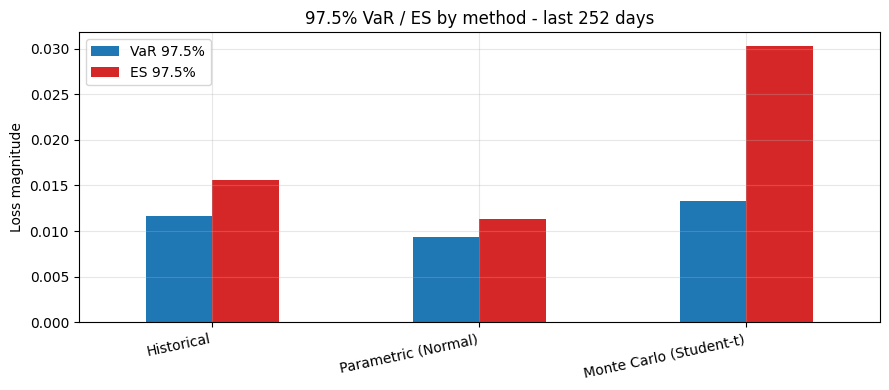

In [4]:
comp.plot(kind='bar', color=['#1f77b4', '#d62728'],
          title=f'97.5% VaR / ES by method - last {VAR_WINDOW} days')
plt.ylabel('Loss magnitude'); plt.xticks(rotation=12, ha='right')
plt.tight_layout(); plt.show()

The Normal model reports the **smallest** ES, while the Student-t fit is far larger. That gap is the cost of assuming away fat tails, and it is exactly why FRTB mandates Expected Shortfall (not just VaR) and an assumption-free or stressed calibration for regulatory capital.

## 3. Risk through time

Rolling 252-day VaR and ES. ES sits above VaR by construction (it averages the losses *beyond* VaR) and the spread widens in turbulent periods.

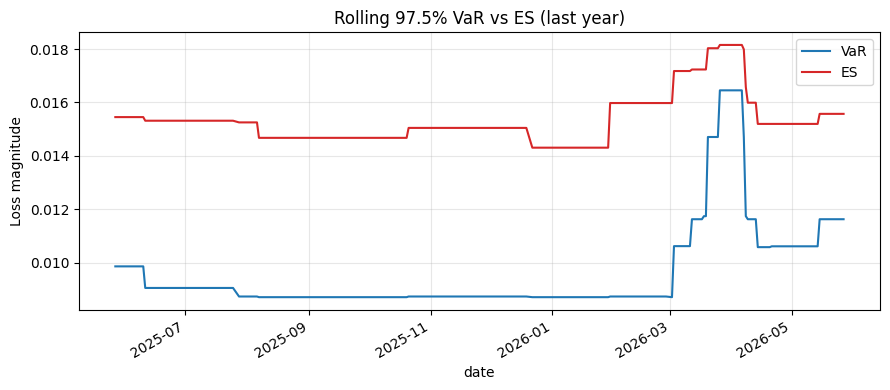

In [5]:
roll = rolling_var_es(port).dropna()
roll.tail(VAR_WINDOW).rename(columns={'var': 'VaR', 'es': 'ES'}).plot(
    title='Rolling 97.5% VaR vs ES (last year)', color=['#1f77b4', '#d62728'])
plt.ylabel('Loss magnitude'); plt.tight_layout(); plt.show()

## 4. Does the model hold up? VaR backtests

Using yesterday's forecast to predict today (no look-ahead), we test the VaR exceedance sequence with two classical likelihood-ratio tests:

- **Kupiec POF** - is the breach rate consistent with the stated 2.5%?
- **Christoffersen** - are breaches independent, or do they cluster (a sign the model reacts too slowly to volatility)?

A small p-value rejects the model.

In [6]:
es_pred, var_pred = roll['es'].shift(1), roll['var'].shift(1)
bt = pd.DataFrame({'R': port, 'var': var_pred, 'es': es_pred}).dropna()
breaches = breaches_from(bt['R'].to_numpy(), bt['var'].to_numpy())
kup = kupiec_pof(breaches, ALPHA)
chr_ = christoffersen(breaches, ALPHA)
print(f"Observations : {kup['T']:,}")
print(f"Breaches     : {kup['x']}  (rate {kup['breach_rate']:.3%}, target {ALPHA:.1%})")
print(f"Kupiec POF      : LR={kup['LR_pof']:.2f}  p={kup['p_value']:.4f}")
print(f"Christoffersen  : independence LR={chr_['LR_ind']:.2f} p={chr_['p_value_ind']:.4f}")
print(f"Conditional cov : LR={chr_['LR_cc']:.2f} p={chr_['p_value_cc']:.4f}")

Observations : 4,560
Breaches     : 143  (rate 3.136%, target 2.5%)
Kupiec POF      : LR=7.01  p=0.0081
Christoffersen  : independence LR=19.67 p=0.0000
Conditional cov : LR=26.68 p=0.0000


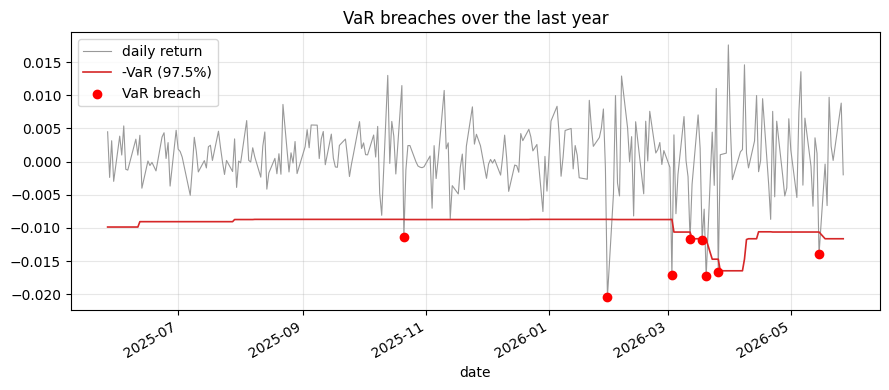

In [7]:
ax = port.tail(VAR_WINDOW).plot(color='#999', lw=0.8, label='daily return')
thr = -roll['var'].shift(1).tail(VAR_WINDOW)
thr.plot(ax=ax, color='#d62728', lw=1.2, label='-VaR (97.5%)')
b = bt.tail(VAR_WINDOW)
bx = b.index[breaches[-VAR_WINDOW:]] if len(breaches) >= VAR_WINDOW else b.index[b['R'] < -b['var']]
ax.scatter(bx, port.loc[bx], color='red', zorder=5, label='VaR breach')
ax.set_title('VaR breaches over the last year'); ax.legend(); plt.tight_layout(); plt.show()

## Takeaways

1. **Distributional choice drives the tail.** Normal VaR/ES materially understates risk versus historical and fat-tailed estimates.
2. **ES is the right capital measure.** It captures the average severity of tail losses, not just their frequency.
3. **Backtesting is non-negotiable.** A model can look reasonable yet fail formal coverage/independence tests, especially around volatility regime shifts.

See the [repository](https://github.com/marksguo/frtb-ima-risk-monitor) for the full automated pipeline, dashboard, and weekly Acerbi-Szekely ES backtesting.